In [ ]:
# EJECUCIÓN SECUENCIAL (OPCIONAL)
# Si deseas ejecutar este código seccionado secuencialmente y heredar las variables del archivo anterior, borra el '#' de la siguiente línea de código:

# %run 02_Preprocesamiento_Otsu.ipynb

### **Detección de Bordes y Morfología para Rotación**

Kernel de suavizado: 5x5
Kernel de dilatación: 3x30
Ángulo de rotación calculado por Transformada de Hough: 1.00 grados


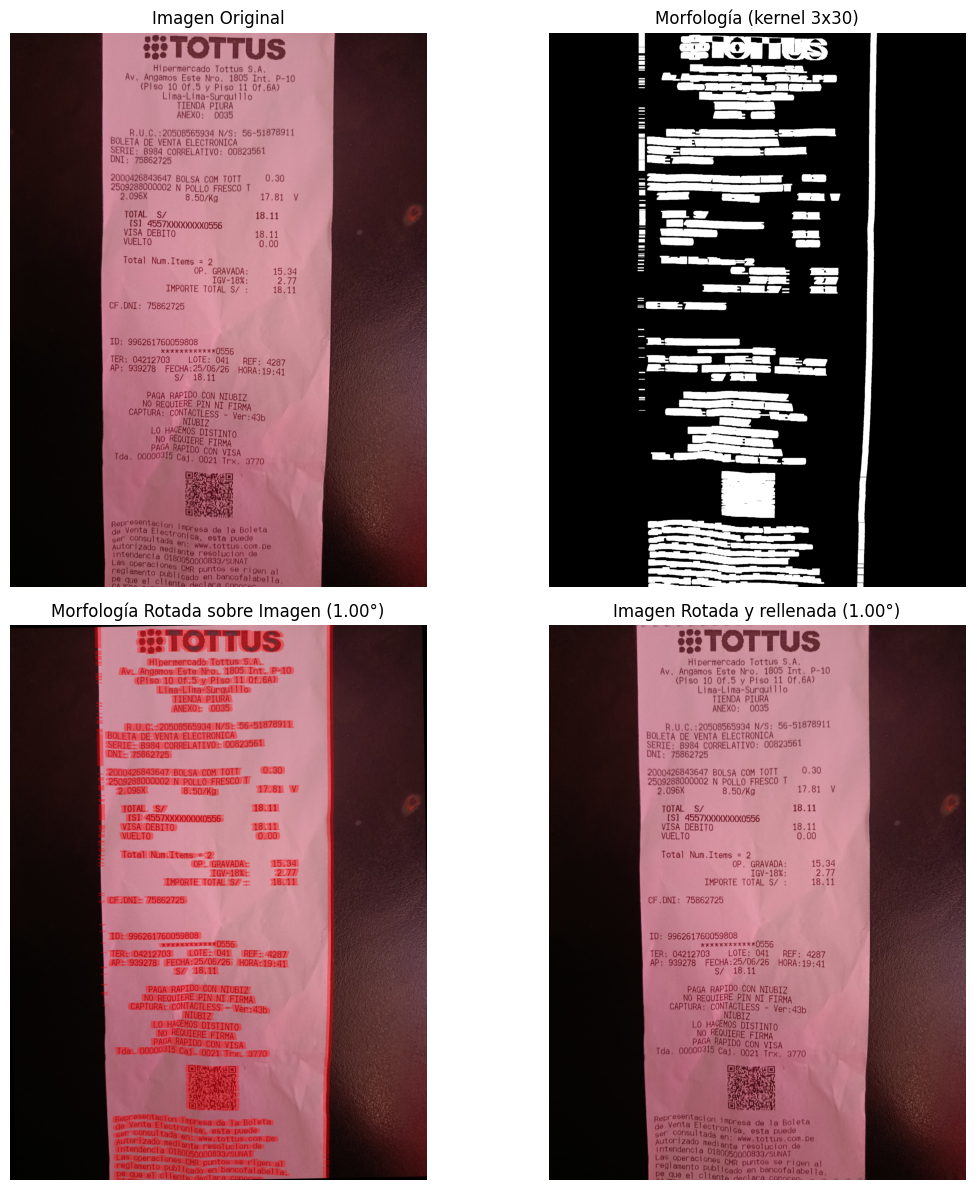

In [ ]:
# DETECCIÓN DE BORDES, MORFOLOGÍA Y CORRECCIÓN DE ROTACIÓN

# Para la detección de bordes dentro de nuestra primera máscara
img_blur = cv2.GaussianBlur(imgG, (k_blur, k_blur), 0)
img_canny_gauss = cv2.Canny(img_blur, 50, 150)
img_canny_gauss = cv2.bitwise_and(img_canny_gauss, img_canny_gauss, mask=mascara_papel_final)

# Dilatación estructural
k_ancho = max(5, round(ancho_des * 0.015))
k_alto = max(1, round(alto_des * 0.001))
estructure = np.ones((k_alto, k_ancho), np.uint8)
morfo_canny_gauss = cv2.dilate(img_canny_gauss, estructure, iterations=1)

print(f"Kernel de suavizado: {k_blur}x{k_blur}")
print(f"Kernel de dilatación: {k_alto}x{k_ancho}")

# Estimación del ángulo dominante (Hough + mediana ponderada por longitud)
rows, cols = imgG.shape

lineas = cv2.HoughLinesP(morfo_canny_gauss, rho=1, theta=np.pi / 180, threshold=50, minLineLength=30, maxLineGap=20)

angulos_detectados = []
pesos_angulos = []

if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        dx, dy = x2 - x1, y2 - y1
        longitud = np.sqrt(dx**2 + dy**2)

        angulo_deg = np.degrees(np.arctan2(dy, dx))

        # Normalización para que orientaciones equivalentes no se traten como distintas
        if angulo_deg > 90:
            angulo_deg -= 180
        elif angulo_deg < -90:
            angulo_deg += 180

        # Solo segmentos aproximadamente horizontales influyen en la estimación
        if -35 < angulo_deg < 35:
            angulos_detectados.append(angulo_deg)
            pesos_angulos.append(longitud)

if angulos_detectados:
    angulos_detectados = np.array(angulos_detectados)
    pesos_angulos = np.array(pesos_angulos)

    indices_ordenados = np.argsort(angulos_detectados)
    angulos_ordenados = angulos_detectados[indices_ordenados]
    pesos_ordenados = pesos_angulos[indices_ordenados]

    suma_pesos = np.sum(pesos_ordenados)
    peso_acumulado = np.cumsum(pesos_ordenados)
    indice_mediana = np.searchsorted(peso_acumulado, suma_pesos / 2)
    theta_optimo = angulos_ordenados[indice_mediana]
else:
    theta_optimo = 0.0

print(f"Ángulo de rotación calculado por Transformada de Hough: {theta_optimo:.2f} grados")

# Rotación de todo lo que se necesitará más adelante
centro_rotacion = (cols / 2, rows / 2)
M_rotacion = cv2.getRotationMatrix2D(centro_rotacion, theta_optimo, 1.0)

# Imagen a color: conserva interpolación lineal para buena calidad visual
img_color_rotada = cv2.warpAffine(img_rees, M_rotacion, (cols, rows))

# MÁSCARAS BINARIAS: Usamos INTER_NEAREST + threshold para garantizar uint8 puro (0 o 255)
morfo_rotada = cv2.warpAffine(morfo_canny_gauss, M_rotacion, (cols, rows), flags=cv2.INTER_NEAREST)

mascara_papel_rotada = cv2.warpAffine(mascara_papel_final, M_rotacion, (cols, rows), flags=cv2.INTER_NEAREST)
_, mascara_papel_rotada = cv2.threshold(mascara_papel_rotada, 127, 255, cv2.THRESH_BINARY)

# Imagen rotada con morfología sobrepuesta
img_color_rotada_copy = img_color_rotada.copy()
alpha = 0.4
base_rgb = cv2.cvtColor(img_color_rotada_copy, cv2.COLOR_BGR2RGB)
capa_roja = np.zeros_like(base_rgb)
capa_roja[:, :] = (255, 0, 0)

mezcla = cv2.addWeighted(base_rgb, 1 - alpha, capa_roja, alpha, 0)

mascara_bool = morfo_rotada > 0
morfo_sobre = base_rgb.copy()
morfo_sobre[mascara_bool] = mezcla[mascara_bool]

# Relleno inteligente
mascara_valida = np.full((rows, cols), 255, dtype=np.uint8)
mascara_valida = cv2.warpAffine(mascara_valida, M_rotacion, (cols, rows), flags=cv2.INTER_NEAREST, borderValue=0)

# Invertimos: ahora el blanco marca justo las zonas a rellenar
mascara_huecos = cv2.bitwise_not(mascara_valida)

img_color_rotada = cv2.inpaint(img_color_rotada, mascara_huecos, inpaintRadius=7, flags=cv2.INPAINT_TELEA)

# Visualización
plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
plt.title("Imagen Original")
plt.imshow(cv2.cvtColor(img_rees, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title(f"Morfología (kernel {k_alto}x{k_ancho})")
plt.imshow(morfo_canny_gauss, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title(f"Morfología Rotada sobre Imagen ({theta_optimo:.2f}°)")
plt.imshow(morfo_sobre)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title(f"Imagen Rotada y rellenada ({theta_optimo:.2f}°)")
plt.imshow(cv2.cvtColor(img_color_rotada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

#### **Rescate de Elemento**

Intento Otsu - Cobertura: 100.0% -> ACEPTADO


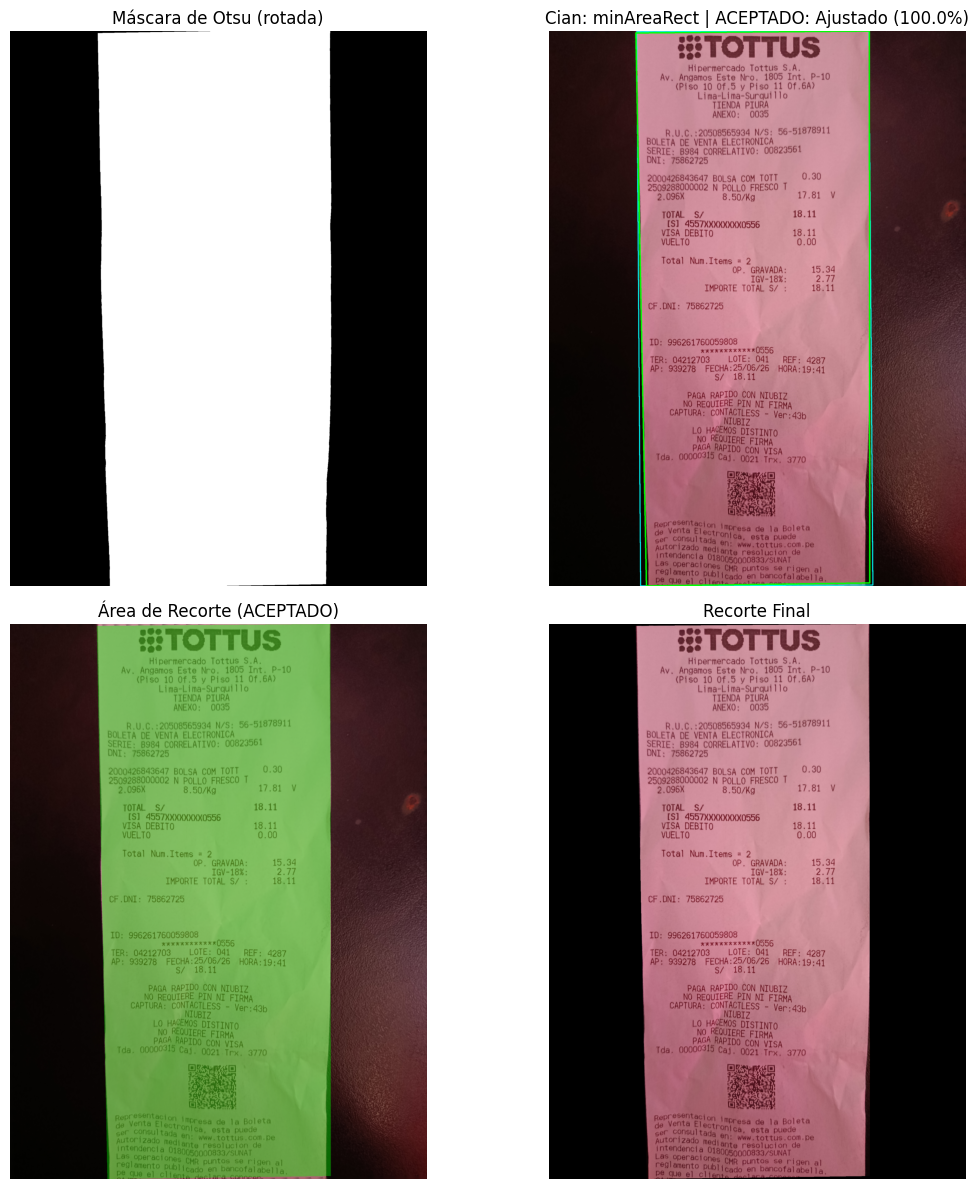

In [ ]:
# Parámetros de control 
N_ITERACIONES = 10
MARGEN_ANGULO_LADO = 10
MARGEN_ROTACION_INICIAL = 10
MARGEN_SIMILITUD = 70
MARGEN_DISTANCIA = max(3, round(ancho_des * 0.02))
PASO_MUESTREO = max(2, round(ancho_des * 0.002))
ALPHA_OVERLAY = 0.4

# Funciones geométricas y de procesamiento 
def distancia_punto_a_segmento(p, a, b):
    ab, ap = b - a, p - a
    t = np.clip(np.dot(ap, ab) / (np.dot(ab, ab) + 1e-9), 0, 1)
    return np.linalg.norm(p - (a + t * ab))

def interseccion_rectas(p1, d1, p2, d2):
    A = np.array([d1, -d2]).T
    if abs(np.linalg.det(A)) < 1e-9: return None
    return p1 + np.linalg.solve(A, p2 - p1)[0] * d1

def diferencia_angular(a1, a2):
    return abs(((a1 - a2 + 90) % 180) - 90)

def muestrear_perimetro(puntos, paso_px):
    muestras = []
    for i in range(4):
        p1, p2 = puntos[i], puntos[(i + 1) % 4]
        n_pasos = max(2, int(np.linalg.norm(p2 - p1) // paso_px))
        muestras.extend([p1 + t * (p2 - p1) for t in np.linspace(0, 1, n_pasos, endpoint=False)])
    return np.array(muestras)

def ajustar_y_validar_cuadrilatero(mascara_entrada, ancho_img, alto_img):
    contornos, _ = cv2.findContours(mascara_entrada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contornos: return False, 0.0, None, None, np.zeros_like(mascara_entrada)
    contorno_mayor = max(contornos, key=cv2.contourArea)
    puntos_hull = cv2.convexHull(contorno_mayor).reshape(-1, 2).astype(np.float64)
    rect_inicial = cv2.minAreaRect(contorno_mayor)
    vertices_iniciales = cv2.boxPoints(rect_inicial).astype(np.float64)
    caja_inicial = np.clip(vertices_iniciales, [0, 0], [ancho_img - 1, alto_img - 1]).astype(np.int32)
    angulo_rect = rect_inicial[2]
    angulo_inicial = abs(90 - abs(angulo_rect)) if abs(angulo_rect) > 45 else abs(angulo_rect)
    if angulo_inicial > MARGEN_ROTACION_INICIAL: return False, 0.0, None, caja_inicial, np.zeros_like(mascara_entrada)
    vertices = vertices_iniciales.copy()
    angulos_originales = [np.degrees(np.arctan2(*(vertices[(i + 1) % 4] - vertices[i])[::-1])) for i in range(4)]
    for _ in range(N_ITERACIONES):
        asignaciones = np.array([np.argmin([distancia_punto_a_segmento(p, vertices[i], vertices[(i + 1) % 4]) for i in range(4)]) for p in puntos_hull])
        lineas_ajustadas = []
        for i in range(4):
            puntos_lado = puntos_hull[asignaciones == i]
            a_actual, b_actual = vertices[i], vertices[(i + 1) % 4]
            d_actual = (b_actual - a_actual) / (np.linalg.norm(b_actual - a_actual) + 1e-9)
            if len(puntos_lado) >= 2:
                vx, vy, x0, y0 = cv2.fitLine(puntos_lado.astype(np.float32), cv2.DIST_L2, 0, 0.01, 0.01).flatten()
                desvio = diferencia_angular(np.degrees(np.arctan2(vy, vx)), angulos_originales[i])
                lineas_ajustadas.append((np.array([x0, y0]), np.array([vx, vy])) if desvio <= MARGEN_ANGULO_LADO else (a_actual, d_actual))
            else:
                lineas_ajustadas.append((a_actual, d_actual))
        nuevas_vertices = []
        for i in range(4):
            p_prev, d_prev = lineas_ajustadas[(i - 1) % 4]
            p_act, d_act = lineas_ajustadas[i]
            interseccion = interseccion_rectas(p_prev, d_prev, p_act, d_act)
            nuevas_vertices.append(interseccion if interseccion is not None else vertices[i])
        vertices = np.array(nuevas_vertices)
    cuadrilatero_final = vertices.astype(np.float32)
    puntos_perimetro = muestrear_perimetro(cuadrilatero_final, PASO_MUESTREO)
    distancias_cobertura = np.array([abs(cv2.pointPolygonTest(contorno_mayor, (float(p[0]), float(p[1])), True)) for p in puntos_perimetro])
    cobertura = np.mean(distancias_cobertura <= MARGEN_DISTANCIA) * 100
    valido = cobertura >= MARGEN_SIMILITUD
    cuadrilatero_dibujo = np.clip(cuadrilatero_final, [0, 0], [ancho_img - 1, alto_img - 1]).astype(np.int32)
    mascara_cuad = np.zeros_like(mascara_entrada)
    cv2.fillPoly(mascara_cuad, [cuadrilatero_dibujo], 255)
    return valido, cobertura, cuadrilatero_dibujo, caja_inicial, mascara_cuad

# Preparación 
alto_img, ancho_img = mascara_papel_rotada.shape
base_rgb = cv2.cvtColor(img_color_rotada, cv2.COLOR_BGR2RGB)


# CADENA ENCASETADA: OTSU -> K-MEANS -> OTSU ROTADA ORIGINAL

valido, cobertura_perimetro, cuadrilatero_dibujo, caja_inicial_dibujo, mascara_cuadrilatero = ajustar_y_validar_cuadrilatero(mascara_papel_rotada, ancho_img, alto_img)
print(f"Intento Otsu - Cobertura: {cobertura_perimetro:.1f}% -> {'ACEPTADO' if valido else 'RECHAZADO'}")

if not valido:
    print("Otsu rechazado. Ejecutando K-Means (K=3) en LAB y análisis encadenado...")
    img_lab_rotada = cv2.cvtColor(img_color_rotada, cv2.COLOR_BGR2LAB)
    ys, xs = np.where(mascara_papel_rotada > 0)
    if len(ys) > 0:
        datos_ab = np.float32(img_lab_rotada[ys, xs, 1:3])
        criterio = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
        cv2.setRNGSeed(42)
        _, etiquetas, _ = cv2.kmeans(datos_ab, 3, None, criterio, 10, cv2.KMEANS_RANDOM_CENTERS)
        etiquetas = etiquetas.ravel()
        pixeles_morfologicos = morfo_canny_gauss[ys, xs] > 0
        conteo_morfologia = np.array([np.sum((etiquetas == i) & pixeles_morfologicos) for i in range(3)])
        orden_morfologia = np.argsort(-conteo_morfologia)
        top1, top2 = orden_morfologia[0], orden_morfologia[1]
        ratio_top2 = conteo_morfologia[top2] / (conteo_morfologia[top1] + 1e-9)
        clusters_validos = [top1, top2] if ratio_top2 >= 0.20 else [top1]
        
        mascara_boleta_filtrada = np.zeros_like(mascara_papel_rotada, dtype=np.uint8)
        for c in clusters_validos:
            sel = etiquetas == c
            mascara_boleta_filtrada[ys[sel], xs[sel]] = 255
            
        val_k, cob_k, cuad_k, caja_k, masc_k = ajustar_y_validar_cuadrilatero(mascara_boleta_filtrada, ancho_img, alto_img)
        print(f"Intento K-Means - Cobertura: {cob_k:.1f}% -> {'ACEPTADO' if val_k else 'RECHAZADO'}")
        
        if val_k:
            valido, cobertura_perimetro, cuadrilatero_dibujo, caja_inicial_dibujo, mascara_cuadrilatero = val_k, cob_k, cuad_k, caja_k, masc_k
            print("Resultado validado exitosamente mediante K-Means.")
        else:
            print("K-Means también fue rechazado. Se adopta por defecto el Otsu rotado original.")

# Selección Final y Visualización 
mascara_seleccion_final = mascara_cuadrilatero if valido else mascara_papel_rotada
img_recorte_final = cv2.bitwise_and(img_color_rotada, img_color_rotada, mask=mascara_seleccion_final)
color_estado = (0, 255, 0) if valido else (255, 0, 0)

img_debug = base_rgb.copy()
if caja_inicial_dibujo is not None: cv2.drawContours(img_debug, [caja_inicial_dibujo], -1, (0, 255, 255), 4)
if cuadrilatero_dibujo is not None: cv2.drawContours(img_debug, [cuadrilatero_dibujo], -1, color_estado, 5)

capa_color = np.full_like(base_rgb, color_estado, dtype=np.uint8)
mezcla = cv2.addWeighted(base_rgb, 1 - ALPHA_OVERLAY, capa_color, ALPHA_OVERLAY, 0)
area_tenida = base_rgb.copy()
area_tenida[mascara_cuadrilatero > 0] = mezcla[mascara_cuadrilatero > 0]

estado = "ACEPTADO" if valido else "RECHAZADO"
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1); plt.title("Máscara de Otsu (rotada)"); plt.imshow(mascara_papel_rotada, cmap='gray'); plt.axis('off')
plt.subplot(2, 2, 2); plt.title(f"Cian: minAreaRect | {estado}: Ajustado ({cobertura_perimetro:.1f}%)"); plt.imshow(img_debug); plt.axis('off')
plt.subplot(2, 2, 3); plt.title(f"Área de Recorte ({estado})"); plt.imshow(area_tenida); plt.axis('off')
plt.subplot(2, 2, 4); plt.title("Recorte Final"); plt.imshow(cv2.cvtColor(img_recorte_final, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.tight_layout()
plt.show()